# Dataset Overview: UCLA Consortium for Neuropsychiatric Phenomics

## Project context

This notebook provides an initial overview of the UCLA Consortium for Neuropsychiatric Phenomics dataset.

The long-term goal of this project is to analyze resting-state fMRI functional connectivity patterns across psychiatric and healthy control groups.

## Research question

Do schizophrenia, bipolar disorder, ADHD, and healthy controls show different functional brain connectivity patterns in resting-state fMRI data?

## Groups of interest

- Healthy controls
- Schizophrenia
- Bipolar disorder
- ADHD

## Current notebook goals

1. Load participant-level metadata.
2. Inspect diagnosis groups.
3. Check demographic distributions.
4. Identify participants with resting-state fMRI data.
5. Prepare a clean participant table for future connectivity analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
participants_url = "https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/participants.tsv"

participants = pd.read_csv(participants_url, sep="\t")

participants.head()

,participant_id,diagnosis,age,gender,bart,bht,dwi,pamenc,pamret,rest,scap,stopsignal,T1w,taskswitch,ScannerSerialNumber
0,sub-10159,CONTROL,30,F,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0
1,sub-10171,CONTROL,24,M,1.0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0
2,sub-10189,CONTROL,49,M,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0
3,sub-10193,CONTROL,40,M,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,35343.0
4,sub-10206,CONTROL,21,M,1.0,NaN,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,35343.0


In [3]:
print(f"Number of participants: {participants.shape[0]}")
print(f"Number of columns: {participants.shape[1]}")

participants.columns.tolist()

Number of participants: 272
Number of columns: 15


['participant_id',
 'diagnosis',
 'age',
 'gender',
 'bart',
 'bht',
 'dwi',
 'pamenc',
 'pamret',
 'rest',
 'scap',
 'stopsignal',
 'T1w',
 'taskswitch',
 'ScannerSerialNumber']

In [4]:
diagnosis_counts = participants["diagnosis"].value_counts(dropna=False)

diagnosis_counts

diagnosis
CONTROL    130
SCHZ        50
BIPOLAR     49
ADHD        43
Name: count, dtype: int64

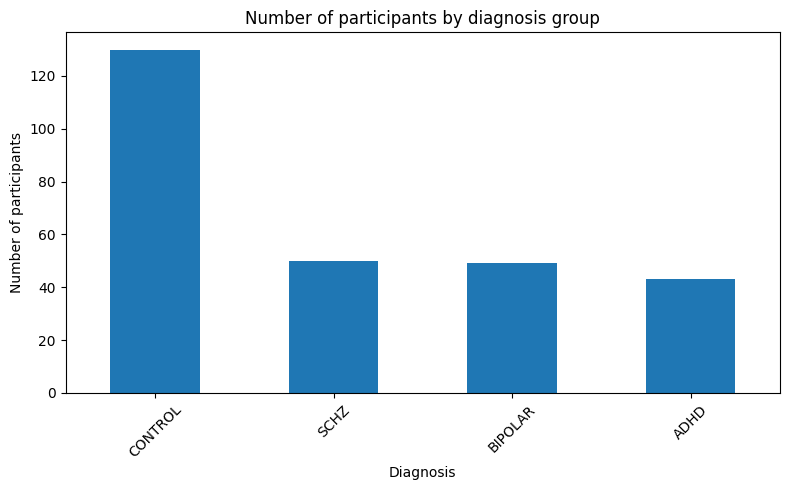

In [6]:
diagnosis_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Number of participants by diagnosis group")
plt.xlabel("Diagnosis")
plt.ylabel("Number of participants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
participants.groupby("diagnosis")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
diagnosis,,,,,,,,
ADHD,43.0,33.093023,10.761072,21.0,24.0,30.0,45.00,50.0
BIPOLAR,49.0,35.285714,9.027735,21.0,26.0,36.0,43.00,50.0
CONTROL,130.0,31.261538,8.736055,21.0,24.0,28.0,39.00,50.0
SCHZ,50.0,36.460000,8.878339,22.0,29.0,37.5,43.75,49.0


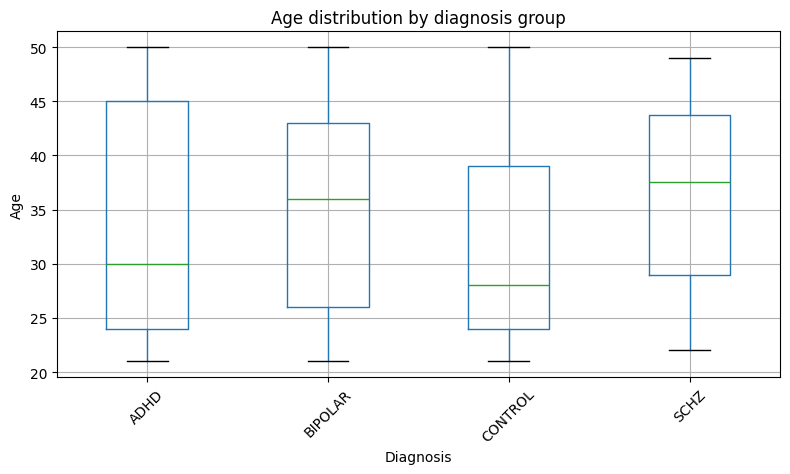

In [8]:
participants.boxplot(column="age", by="diagnosis", figsize=(8, 5))

plt.title("Age distribution by diagnosis group")
plt.suptitle("")
plt.xlabel("Diagnosis")
plt.ylabel("Age")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
gender_counts = pd.crosstab(participants["diagnosis"], participants["gender"])

gender_counts

gender,F,M
diagnosis,,
ADHD,22,21
BIPOLAR,21,28
CONTROL,62,68
SCHZ,12,38


In [10]:
rest_counts = participants["rest"].value_counts(dropna=False)

rest_counts

rest
1.0    268
NaN      4
Name: count, dtype: int64

In [11]:
participants_with_rest = participants[participants["rest"] == 1].copy()

print(f"Participants with resting-state fMRI: {participants_with_rest.shape[0]}")

participants_with_rest["diagnosis"].value_counts()

Participants with resting-state fMRI: 268


diagnosis
CONTROL    127
SCHZ        50
BIPOLAR     49
ADHD        42
Name: count, dtype: int64

In [13]:
columns_to_keep = [
    "participant_id",
    "diagnosis",
    "age",
    "gender",
    "rest",
    "T1w",
    "ScannerSerialNumber"
]

existing_columns = [col for col in columns_to_keep if col in participants_with_rest.columns]

analysis_participants = participants_with_rest[existing_columns].copy()

analysis_participants.head()

,participant_id,diagnosis,age,gender,rest,T1w,ScannerSerialNumber
0,sub-10159,CONTROL,30,F,1.0,1.0,35343.0
1,sub-10171,CONTROL,24,M,1.0,1.0,35343.0
2,sub-10189,CONTROL,49,M,1.0,1.0,35343.0
4,sub-10206,CONTROL,21,M,1.0,1.0,35343.0
5,sub-10217,CONTROL,33,F,1.0,1.0,35343.0


In [14]:
output_path = "../data/processed/participants_with_rest.tsv"

analysis_participants.to_csv(output_path, sep="\t", index=False)

print(f"Saved to: {output_path}")

Saved to: ../data/processed/participants_with_rest.tsv


In [15]:
participants.columns.tolist()

['participant_id',
 'diagnosis',
 'age',
 'gender',
 'bart',
 'bht',
 'dwi',
 'pamenc',
 'pamret',
 'rest',
 'scap',
 'stopsignal',
 'T1w',
 'taskswitch',
 'ScannerSerialNumber']

## Summary

This notebook loaded and inspected participant-level metadata from the UCLA CNP dataset.

Key outputs:

- diagnosis group counts;
- demographic overview;
- resting-state fMRI availability;
- clean participant table for future connectivity analysis.

Next step:

Build a pipeline for downloading a small subset of resting-state fMRI data and extracting regional BOLD time series using a brain atlas.